# Week 6 live coding: splitting, tuning, and leakage

A 45-minute tutorial to type through together. Every number a model reports is a claim about
how it will do on data it has not seen. This week is about making that claim true. We score
one model under three different splits, see one split fail and understand why, find a model
whose score depends entirely on the split, tune a model two ways, with a validation block and
with cross-validation, and finish with two kinds of leakage.

We work with **daily streamflow at three river gauges** from the US Geological Survey, 1990
to the present: the Delaware River in New York, the Willamette River in Oregon, and the
Yellowstone River in Montana. Three rivers, three climates, three very different annual
cycles. The task is to predict the flow **one week ahead** from what the gauge shows today.
Assignment 6 applies the same ideas to a different problem, correcting a low-cost air
quality sensor against a reference instrument, so nothing here is the answer to the
assignment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("pandas ", pd.__version__)
print("sklearn", sklearn.__version__)

pandas  2.3.3
sklearn 1.7.2


## 1. Load three rivers

The USGS water data API returns one CSV per gauge. Parameter code `00060` is discharge in
cubic feet per second and statistic `00003` is the daily mean. The three gauges:

| gauge | river | regime |
|---|---|---|
| `USGS-01434000` | Delaware River at Port Jervis, NY | rain all year plus a spring snowmelt pulse |
| `USGS-14191000` | Willamette River at Salem, OR | winter rain, dry summers |
| `USGS-06191500` | Yellowstone River at Corwin Springs, MT | one big snowmelt peak in June |

In [2]:
gauges = {"USGS-01434000": "Delaware",
          "USGS-14191000": "Willamette",
          "USGS-06191500": "Yellowstone"}

frames = []
for gauge_id, river in gauges.items():
    url = ("https://api.waterdata.usgs.gov/ogcapi/v0/collections/daily/items?f=csv"
           f"&monitoring_location_id={gauge_id}&parameter_code=00060&statistic_id=00003"
           "&time=1990-01-01/2025-12-31&limit=20000")
    d = pd.read_csv(url, usecols=["time", "value"], parse_dates=["time"])
    d["river"] = river
    frames.append(d)

q = pd.concat(frames).rename(columns={"time": "date", "value": "flow_cfs"})
q = q.sort_values(["river", "date"]).reset_index(drop=True)

print(q.shape)
print(q.groupby("river")["date"].agg(["min", "max", "size"]))
print(q.groupby("river")["flow_cfs"].median().rename("median flow, cfs"))

(39447, 3)
                   min        max   size
river                                   
Delaware    1990-01-01 2025-12-31  13149
Willamette  1990-01-01 2025-12-31  13149
Yellowstone 1990-01-01 2025-12-31  13149
river
Delaware        3580.0
Willamette     14800.0
Yellowstone     1380.0
Name: median flow, cfs, dtype: float64


Flows span two orders of magnitude between rivers and within a year, so we work with the
**natural log of flow**. That makes errors relative: an error of 0.1 in log flow is about a
10 percent error in flow, and an error of 0.4 is a factor of about 1.5 either way. One year of
each river shows how different the three regimes are.

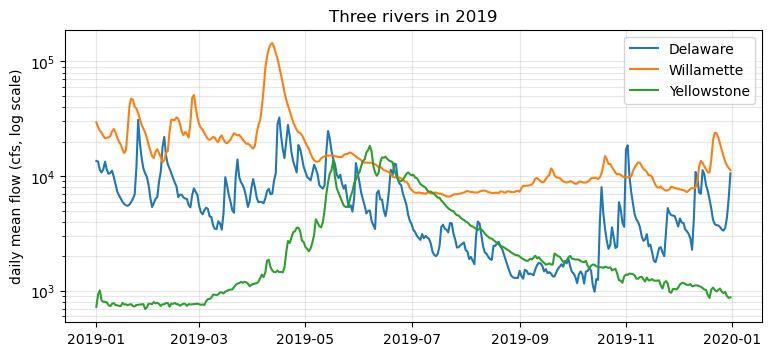

In [3]:
q["logq"] = np.log(q["flow_cfs"])

fig, ax = plt.subplots(figsize=(9, 3.8))
year = q[(q["date"] >= "2019-01-01") & (q["date"] < "2020-01-01")]
for river, g in year.groupby("river"):
    ax.plot(g["date"], g["flow_cfs"], label=river)
ax.set_yscale("log")
ax.set_ylabel("daily mean flow (cfs, log scale)")
ax.set_title("Three rivers in 2019")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()

## 2. The task, the model, and the baseline it has to beat

**Label:** log flow seven days from today, built **within each river** so that the Delaware's
last row does not borrow the Willamette's first. **Features:** today's log flow, how much it
has changed over the past three days (rising or falling), and the day of year as a sine and
cosine pair, as in Week 4.

The model is a **k-nearest-neighbors regressor**: to predict a day, find the $k$ most similar
days in the training set and average their outcomes. It has one knob, $k$, and it is flexible
enough to memorize the training data when $k$ is small. That flexibility is what makes it
useful for showing how validation can go wrong.

The baseline is **persistence**: the flow in a week equals the flow today. The lecture's first
rule: no score means anything until it sits next to this number.

In [4]:
by_river = q.groupby("river")["logq"]
q["logq_in_7d"] = by_river.shift(-7)          # the label: log flow one week ahead
q["dlogq_3d"] = q["logq"] - by_river.shift(3) # rising or falling over the last three days

doy = q["date"].dt.dayofyear
q["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
q["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

q = q.dropna(subset=["logq_in_7d", "dlogq_3d"]).reset_index(drop=True)

features = ["logq", "dlogq_3d", "doy_sin", "doy_cos"]
X = q[features].values
y = q["logq_in_7d"].values
print("rows:", len(q), "| features:", features)

rows: 39417 | features: ['logq', 'dlogq_3d', 'doy_sin', 'doy_cos']


In [5]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

def knn(k):
    # Scaling goes inside the pipeline, so it is always fitted on training data only.
    return make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k))

print(f"persistence RMSE over all rows: {rmse(y, q['logq'].values):.3f} (log flow)")

persistence RMSE over all rows: 0.447 (log flow)


## 3. Same data, same model, three splits

Each split answers a different question.

**Split A, random.** `train_test_split` shuffles the rows. It is the default in every tutorial
on the internet, and it answers the question "can the model fill in a missing week when it
has seen the weeks around it?"

In [6]:
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=0)
model = knn(5).fit(Xtr, ytr)
print(f"random split, k=5:      RMSE = {rmse(yte, model.predict(Xte)):.3f}")

random split, k=5:      RMSE = 0.429


**Split B, forward in time.** Train on everything before 2018, test on 2018 onward, at all
three rivers. This is the question a forecaster faces.

In [7]:
before = (q["date"] < "2018-01-01").values
model = knn(5).fit(X[before], y[before])
print(f"time split, k=5:        RMSE = {rmse(y[~before], model.predict(X[~before])):.3f}")
print(f"persistence, same rows: RMSE = {rmse(y[~before], q['logq'].values[~before]):.3f}")

time split, k=5:        RMSE = 0.440
persistence, same rows: RMSE = 0.433


**Split C, hold out a river.** Train on two rivers, test on the third, each river taking a
turn. This asks whether the model has learned something about rivers or something about
three particular gauges. In Assignment 6 the equivalent is training a sensor correction at one
site and deploying it at another.

In [8]:
for river in gauges.values():
    held_out = (q["river"] == river).values
    model = knn(5).fit(X[~held_out], y[~held_out])
    print(f"held-out {river:12s} k=5:  RMSE = {rmse(y[held_out], model.predict(X[held_out])):.3f}"
          f"   (persistence there: {rmse(y[held_out], q['logq'].values[held_out]):.3f})")

held-out Delaware     k=5:  RMSE = 0.934   (persistence there: 0.606)


held-out Willamette   k=5:  RMSE = 0.851   (persistence there: 0.409)
held-out Yellowstone  k=5:  RMSE = 0.777   (persistence there: 0.256)


Splits A and B agree to within about a hundredth, and both sit close to persistence. Split C
is a different model, worse than persistence on every river by a factor of 1.5 to 3. Same
data, same code, same $k$.
Before explaining it, the same three questions as cross-validation.

**Cross-validation** does the same thing with every fold taking a turn as the test set, which
uses the data more efficiently and gives a spread rather than a single number. scikit-learn has
a splitter for each of the three questions.

Before the scores, look at what each splitter does with the rows. The figure shows, for each
round of a cross-validation, which river-years land in the test fold: each block of three
rows is one round, one row per river, and the columns are years. Shuffled `KFold` tests a
fifth of every river-year in every round. `TimeSeriesSplit` tests only years after the ones
it trained on. `GroupKFold` with the river as the group tests one whole river per round and
never trains on it.

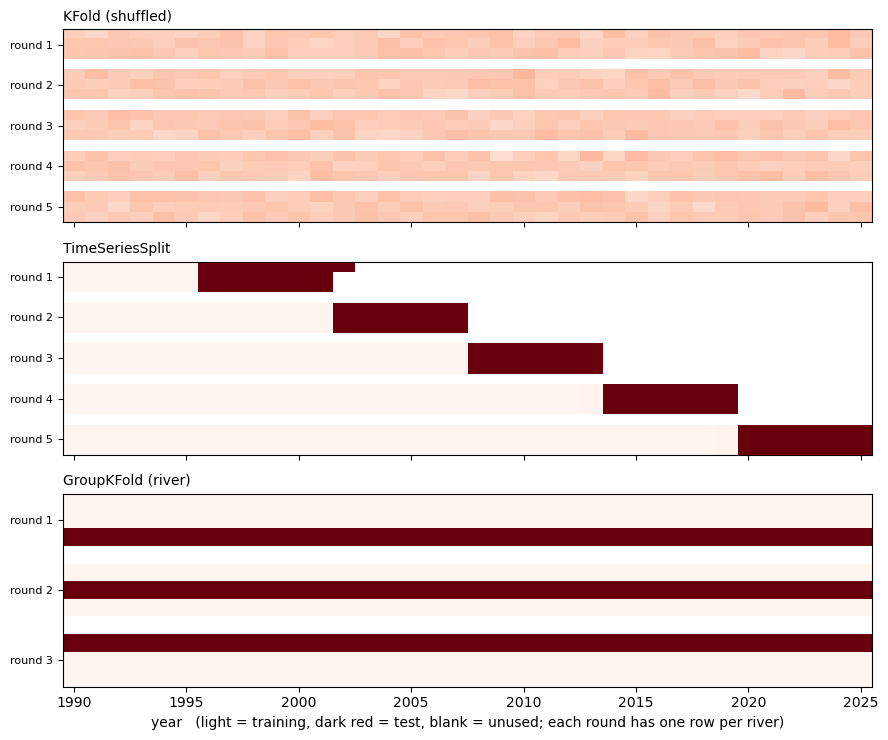

In [9]:
from sklearn.model_selection import KFold, TimeSeriesSplit, GroupKFold

order = np.argsort(q["date"].values, kind="stable")      # date order, which TimeSeriesSplit needs
go = q["river"].values[order]
years_o = q["date"].dt.year.values[order]
rivers = list(gauges.values()); year_list = np.arange(years_o.min(), years_o.max() + 1)

splitters = [("KFold (shuffled)",   KFold(n_splits=5, shuffle=True, random_state=0), None),
             ("TimeSeriesSplit",    TimeSeriesSplit(n_splits=5),                     None),
             ("GroupKFold (river)", GroupKFold(n_splits=3),                          go)]

fig, axes = plt.subplots(3, 1, figsize=(9, 7.5), sharex=True)
for ax, (name, cv, groups) in zip(axes, splitters):
    rounds = list(cv.split(np.zeros(len(order)), groups=groups))
    grid = np.full((len(rounds) * 4 - 1, len(year_list)), np.nan)    # a blank row between rounds
    for r, (train_idx, test_idx) in enumerate(rounds):
        in_test = np.zeros(len(order), bool); in_test[test_idx] = True
        used = np.zeros(len(order), bool); used[train_idx] = True; used[test_idx] = True
        for i, river in enumerate(rivers):
            for j, yr in enumerate(year_list):
                sel = (go == river) & (years_o == yr) & used        # rows a round neither trains nor tests on stay blank
                grid[r * 4 + i, j] = in_test[sel].mean() if sel.any() else np.nan
    ax.imshow(grid, cmap="Reds", vmin=0, vmax=1, aspect="auto",
              extent=[year_list[0] - 0.5, year_list[-1] + 0.5, grid.shape[0] - 0.5, -0.5])
    ax.set_yticks([r * 4 + 1 for r in range(len(rounds))]); ax.set_yticklabels([f"round {r + 1}" for r in range(len(rounds))], fontsize=8)
    ax.set_title(name, fontsize=10, loc="left")
axes[-1].set_xlabel("year   (light = training, dark red = test, blank = unused; each round has one row per river)")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import cross_val_score

Xo, yo = X[order], y[order]            # features and labels in date order, to match the splitters

for name, cv, groups in splitters:
    scores = -cross_val_score(knn(5), Xo, yo, groups=groups, cv=cv, scoring="neg_root_mean_squared_error")
    print(f"{name:20s} RMSE = {scores.mean():.3f} ± {scores.std():.3f}  (folds: {np.round(scores, 3)})")

KFold (shuffled)     RMSE = 0.416 ± 0.008  (folds: [0.407 0.416 0.406 0.419 0.429])
TimeSeriesSplit      RMSE = 0.466 ± 0.028  (folds: [0.483 0.505 0.471 0.429 0.44 ])


GroupKFold (river)   RMSE = 0.854 ± 0.064  (folds: [0.777 0.851 0.934])


Now the explanation. The first feature is today's log flow, and the Willamette runs at ten
times the Yellowstone's level all year. Trained on the other two rivers, the model has never
seen a day at the held-out river's level in the held-out river's season, so its nearest
neighbors are the wrong river's days. It has learned where each gauge sits, not how rivers
behave. The random and time splits never exposed this because every test row had training
rows from the same river.

The fix is to ask the question the model can transfer: express each river's flow as an
**anomaly** from its own long-term mean, and predict the anomaly. Same split, same model, and
the held-out river's error drops by a third or more. On the Delaware it lands at persistence.
On the Yellowstone it stays well above, because nothing in a rain-fed river teaches the timing
of a snowmelt peak.

In [11]:
river_mean = q.groupby("river")["logq"].transform("mean")
q["anom"] = q["logq"] - river_mean
q["anom_in_7d"] = q["logq_in_7d"] - river_mean

Xa = q[["anom", "dlogq_3d", "doy_sin", "doy_cos"]].values
ya = q["anom_in_7d"].values

for river in gauges.values():
    held_out = (q["river"] == river).values
    model = knn(5).fit(Xa[~held_out], ya[~held_out])
    print(f"held-out {river:12s} anomaly features:  RMSE = {rmse(ya[held_out], model.predict(Xa[held_out])):.3f}")

held-out Delaware     anomaly features:  RMSE = 0.605
held-out Willamette   anomaly features:  RMSE = 0.473
held-out Yellowstone  anomaly features:  RMSE = 0.616


A split that matches the application found a flaw that the default split hid, and the flaw
turned out to be in the features, not the model. That is the usual pattern.

## 4. When the split changes everything

Now change one thing. Drop today's flow from the features and give the model only the
**calendar**: the day of year, and the number of years since 1990. The target is the 15-day
running mean of log flow, the kind of smooth seasonal signal a lot of climate work predicts.
With these features the model can only say "what was the river like at this time of year, in
this year?" We use one river, the Yellowstone, so that the calendar identifies a single day.

In [12]:
ys = q[q["river"] == "Yellowstone"].copy()
ys["logq_smooth"] = ys["logq"].rolling(15, center=True).mean()
ys["years_since_1990"] = (ys["date"] - pd.Timestamp("1990-01-01")).dt.days / 365.25
ys = ys.dropna(subset=["logq_smooth"])

Xc = ys[["doy_sin", "doy_cos", "years_since_1990"]].values
yc = ys["logq_smooth"].values
before_c = (ys["date"] < "2018-01-01").values

Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.2, random_state=0)
print(f"calendar model, random split: RMSE = {rmse(yte, knn(1).fit(Xtr, ytr).predict(Xte)):.3f}")

m = knn(1).fit(Xc[before_c], yc[before_c])
print(f"calendar model, time split:   RMSE = {rmse(yc[~before_c], m.predict(Xc[~before_c])):.3f}")

# Climatology for the same target: mean by day of year over the training years.
clim = ys[before_c].groupby(ys[before_c]["date"].dt.dayofyear)["logq_smooth"].mean()
clim_pred = clim.reindex(ys[~before_c]["date"].dt.dayofyear).values
print(f"climatology, time split:      RMSE = {rmse(yc[~before_c], clim_pred):.3f}")

calendar model, random split: RMSE = 0.029
calendar model, time split:   RMSE = 0.486
climatology, time split:      RMSE = 0.254


Under a random split the calendar model is nearly perfect, ten times better than climatology.
Under a time split it is twice as bad as climatology. Nothing about the model changed. What
changed is that the random split let it find, for each test day, the days immediately before
and after it in the *same year*, which sit on the same smooth curve. It was interpolating, and
interpolation is easy. The time split asked it to forecast a new year's snowmelt, and it had
nothing to forecast with.

This is the autocorrelation problem from the lecture in its purest form, and it is how
seemingly skillful models get published on climate data. Any feature that identifies *when* or
*where* a sample was taken, a timestamp, a gauge ID, a latitude, a year, gives a flexible
model a way to look up its neighbors instead of learning a relationship. Random
cross-validation cannot tell the difference. A split that matches the application can.

## 5. Tuning a model without cheating

Back to the flow-feature model. $k$ has to be chosen. If we pick the $k$ that scores best on
the test set, the test score is no longer a prediction of future performance: we have used
the test data to make a decision, and we would pick a lucky $k$ as readily as a good one.

The fix is a third slice. **Training** data fits the model, **validation** data chooses $k$,
and the **test** data is touched once, at the end, to report the number. Here all three are
consecutive in time.

train / validation / test rows: 24096 6576 8745


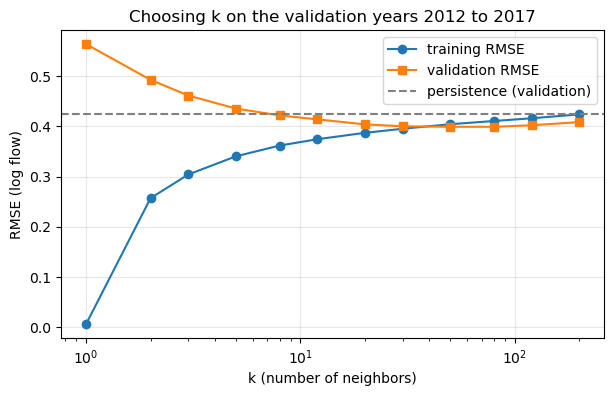

best k on validation: 50


In [13]:
dates = q["date"].values[order]
train = dates < np.datetime64("2012-01-01")
valid = (dates >= np.datetime64("2012-01-01")) & (dates < np.datetime64("2018-01-01"))
test  = dates >= np.datetime64("2018-01-01")
print("train / validation / test rows:", train.sum(), valid.sum(), test.sum())

ks = [1, 2, 3, 5, 8, 12, 20, 30, 50, 80, 120, 200]
train_err, valid_err = [], []
for k in ks:
    m = knn(k).fit(Xo[train], yo[train])
    train_err.append(rmse(yo[train], m.predict(Xo[train])))
    valid_err.append(rmse(yo[valid], m.predict(Xo[valid])))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, train_err, "o-", label="training RMSE")
ax.plot(ks, valid_err, "s-", label="validation RMSE")
ax.axhline(rmse(yo[valid], Xo[valid][:, 0]), color="gray", ls="--", label="persistence (validation)")
ax.set_xscale("log")
ax.set_xlabel("k (number of neighbors)")
ax.set_ylabel("RMSE (log flow)")
ax.set_title("Choosing k on the validation years 2012 to 2017")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

best_k = ks[int(np.argmin(valid_err))]
print("best k on validation:", best_k)

The two curves tell the whole overfitting story. At $k=1$ the training error is zero, because
every day is its own nearest neighbor, and the validation error is at its worst. As $k$ grows
the model averages over more days, training error rises, validation error falls, and then
turns back up when it starts averaging over days that are no longer similar. The minimum of the
validation curve is the $k$ to use. Notice that $k=5$, which we used above without thinking,
does not beat persistence, and the tuned model does.

**The same choice by cross-validation.** One validation block is one draw. The alternative
is to let every year before 2018 take a turn as the validation block, which is k-fold
cross-validation on the training years, with a splitter that respects time.
`GridSearchCV` runs the sweep for you: it takes the pipeline, the list of candidate $k$,
and the splitter, fits every combination, and keeps the $k$ with the best mean score. The
second search uses shuffled folds instead, to show what the wrong splitter does to a
tuning decision.

In [14]:
from sklearn.model_selection import GridSearchCV

pre2018 = train | valid                                       # the search never sees the test years
grid = {"kneighborsregressor__n_neighbors": ks}

for name, cv in [("TimeSeriesSplit", TimeSeriesSplit(n_splits=5)),
                 ("KFold (shuffled)", KFold(n_splits=5, shuffle=True, random_state=0))]:
    search = GridSearchCV(knn(1), grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
    search.fit(Xo[pre2018], yo[pre2018])
    chosen = search.best_params_["kneighborsregressor__n_neighbors"]
    print(f"{name:17s} chooses k = {chosen:3d}   cross-validated RMSE = {-search.best_score_:.3f}"
          f"   test RMSE of that choice = {-search.score(Xo[test], yo[test]):.3f}")
print(f"\nthe validation block above chose k = {best_k}")

TimeSeriesSplit   chooses k =  50   cross-validated RMSE = 0.440   test RMSE of that choice = 0.396


KFold (shuffled)  chooses k =  20   cross-validated RMSE = 0.404   test RMSE of that choice = 0.404

the validation block above chose k = 50


Forward-chaining cross-validation lands on the same $k$ as the single validation block,
which is reassuring, and its cross-validated error is a little pessimistic because its
early folds train on only a few years. The shuffled search chooses a smaller $k$ and
reports a better-looking number, and that choice does worse on the test years. Random folds
did not just flatter the score. They changed the decision. When the application is a
forecast, the tuning has to be a forecast too.

Now, and only now, the test set.

In [15]:
final = knn(best_k).fit(Xo[train | valid], yo[train | valid])
print(f"k={best_k}, test years 2018 onward: RMSE = {rmse(yo[test], final.predict(Xo[test])):.3f}")
print(f"persistence on the same years:      RMSE = {rmse(yo[test], Xo[test][:, 0]):.3f}")

k=50, test years 2018 onward: RMSE = 0.396
persistence on the same years:      RMSE = 0.433


Refitting on training plus validation before the final test is normal practice: the choice of
$k$ has been made, so there is no longer any reason to hold those years back.

## 6. Leakage

Leakage is when information from the test set, or from the future, reaches the model during
training. It produces scores that are too good and models that fail on deployment. Two common
forms.

**Leakage through preprocessing.** Fitting a scaler on all the data before splitting lets the
test set's mean and spread into the training step. For a scaler on this much data the effect is
tiny, but the habit is what matters, because the same mistake with an imputer, a feature
selector, or a target encoder is large. The pipeline above did it correctly by construction.
The cell below does it wrong on purpose.

In [16]:
# Wrong: scaler sees every row, including the test years.
scaler_all = StandardScaler().fit(Xo)
wrong = KNeighborsRegressor(n_neighbors=best_k).fit(scaler_all.transform(Xo[train | valid]), yo[train | valid])
print(f"scaler fitted on all rows:      RMSE = {rmse(yo[test], wrong.predict(scaler_all.transform(Xo[test]))):.4f}")

# Right: the pipeline fits the scaler on training rows only.
print(f"scaler inside the pipeline:     RMSE = {rmse(yo[test], final.predict(Xo[test])):.4f}")

scaler fitted on all rows:      RMSE = 0.3963


scaler inside the pipeline:     RMSE = 0.3964


**Leakage through a feature.** Far more dangerous, and easy to do by accident. Hydrographs are
noisy, so a natural step is to smooth the flow before building features. pandas makes the
smoothing window **centered** if you ask, which means the smoothed value for today averages
the seven days before and the seven days after. The seven days after include the day we are
trying to predict.

In [17]:
q["logq_smooth_centered"] = q.groupby("river")["logq"].transform(lambda s: s.rolling(15, center=True).mean())
q["logq_smooth_trailing"] = q.groupby("river")["logq"].transform(lambda s: s.rolling(15).mean())

lk = q.dropna(subset=["logq_smooth_centered", "logq_smooth_trailing"]).sort_values("date")
yl = lk["logq_in_7d"].values
tr_l = (lk["date"] < "2018-01-01").values
te_l = ~tr_l

for extra in ["logq_smooth_centered", "logq_smooth_trailing"]:
    Xl = lk[features + [extra]].values
    m = knn(best_k).fit(Xl[tr_l], yl[tr_l])
    print(f"with {extra:22s} as a feature: RMSE = {rmse(yl[te_l], m.predict(Xl[te_l])):.3f}")
print("(compare the legitimate model above)")

with logq_smooth_centered   as a feature: RMSE = 0.327


with logq_smooth_trailing   as a feature: RMSE = 0.394
(compare the legitimate model above)


The centered version improves the score by more than all the legitimate tuning above
achieved, and nothing in the code looks wrong. No error, no warning, just a model that would
be useless the moment it was asked for a real forecast, because the feature it leans on does
not exist until a week after the forecast is due. The trailing window, which uses only the
past, changes nothing. The only defense is to ask, for every feature, "would I have this
number at the time the prediction is needed?"

## 7. Does the model degrade over time?

A last check that is specific to environmental data. The rivers in the test years are not
the rivers in the training years: snowpack, reservoir rules, and rainfall all change. Score
the final model one test year at a time.

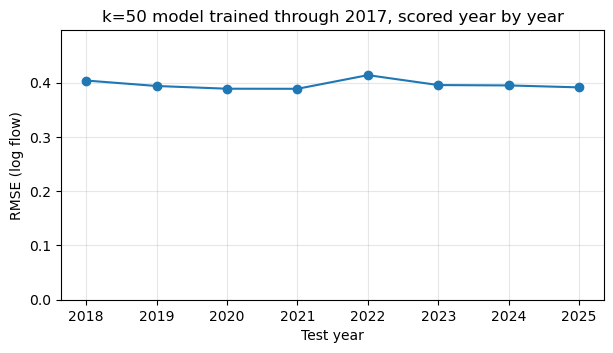

year
2018    0.404
2019    0.394
2020    0.389
2021    0.389
2022    0.414
2023    0.396
2024    0.395
2025    0.391
Name: err, dtype: float64


In [18]:
years = pd.DatetimeIndex(dates[test]).year
pred_test = final.predict(Xo[test])
by_year = pd.DataFrame({"year": years, "err": (yo[test] - pred_test) ** 2}).groupby("year")["err"].mean() ** 0.5

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(by_year.index, by_year.values, "o-")
ax.set_ylim(0, 1.2 * by_year.max())
ax.set_xlabel("Test year")
ax.set_ylabel("RMSE (log flow)")
ax.set_title(f"k={best_k} model trained through 2017, scored year by year")
ax.grid(alpha=0.3)
plt.show()
print(by_year.round(3))

For a one-week forecast there is no trend, because persistence carries most of the skill and
persistence does not care what decade it is. For anything that depends on the *level* of the
flow rather than its week-to-week change, this plot is where the trouble shows up first, and
the emulation and forecasting weeks return to it.

## Where this goes next

The recipe: pick the split that matches the question, hold a test set back until the very
end, tune on validation data, and audit every feature for information from the future or from
the sample's identity. That is most of what separates a model that works in the paper from
one that works in the world. Assignment 6 asks you to run the recipe on a sensor calibration
problem, where the gap between a random split and a chronological one is large, and to find
the leakage yourself.